# ME515 Project: 2D FEM Static and Modal Analysis of a Cantilever Beam

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve, eigsh



E = 210e9  # Young's modulus in Pa
nu = 0.30   # Poisson's ratio
rho = 7850  # Density in kg/m^3
thickness = 1.0  # Beam thickness in m
ty = 1000.0  # Uniform load in N/m, downward

L = float(input("Beam length L in m: ")) # Beam length in m
H = float(input("Beam height H in m: ")) # Beam height in m
nx = int(input("Number of elements in x-direction: "))  # Number of elements in x-direction
ny = int(input("Number of elements in y-direction: "))  # Number of elements in y-direction


point_A = np.array([L / 2.0, -H / 2.0])


print(f"L = {L:g} m, H = {H:g} m, L/H = {L/H:g}")
print(f"mesh = {nx} x {ny}")
print(f"Point A = [{point_A[0]:g}, {point_A[1]:g}]")

L = 20 m, H = 2.5 m, L/H = 8
mesh = 100 x 25
Point A = [10, -1.25]


## FEM functions

In [52]:
def plane_stress_matrix(E, nu):
    c = E / (1.0 - nu**2)
    return c * np.array([
        [1.0, nu, 0.0],
        [nu, 1.0, 0.0],
        [0.0, 0.0, (1.0 - nu) / 2.0]
    ])


def q4_shape(xi, eta):
    N = 0.25 * np.array([
        (1.0 - xi) * (1.0 - eta),
        (1.0 + xi) * (1.0 - eta),
        (1.0 + xi) * (1.0 + eta),
        (1.0 - xi) * (1.0 + eta)
    ])

    dN_dxi = 0.25 * np.array([
        [-(1.0 - eta), -(1.0 - xi)],
        [ (1.0 - eta), -(1.0 + xi)],
        [ (1.0 + eta),  (1.0 + xi)],
        [-(1.0 + eta),  (1.0 - xi)]
    ])

    return N, dN_dxi


def q4_B_matrix(coords, xi, eta):
    N, dN_dxi = q4_shape(xi, eta)

    J = dN_dxi.T @ coords
    detJ = abs(np.linalg.det(J))

    

    dN_dx = dN_dxi @ np.linalg.inv(J)

    B = np.zeros((3, 8))
    for a in range(4):
        B[0, 2*a] = dN_dx[a, 0]
        B[1, 2*a + 1] = dN_dx[a, 1]
        B[2, 2*a] = dN_dx[a, 1]
        B[2, 2*a + 1] = dN_dx[a, 0]

    return B, detJ, N


def element_matrices(coords, E, nu, rho, thickness):
    D = plane_stress_matrix(E, nu)

    ke = np.zeros((8, 8))
    me = np.zeros((8, 8))

    g = 1.0 / np.sqrt(3.0)
    gauss_points = [(-g, -g), (g, -g), (g, g), (-g, g)]

    for xi, eta in gauss_points:
        B, detJ, N = q4_B_matrix(coords, xi, eta)

        ke += B.T @ D @ B * thickness * detJ

        Nmat = np.zeros((2, 8))
        for a in range(4):
            Nmat[0, 2*a] = N[a]
            Nmat[1, 2*a + 1] = N[a]

        me += rho * thickness * (Nmat.T @ Nmat) * detJ

    return ke, me


def make_mesh(L, H, nx, ny):
    xs = np.linspace(0.0, L, nx + 1)
    ys = np.linspace(-H / 2.0, H / 2.0, ny + 1)

    nodes = []
    for y in ys:
        for x in xs:
            nodes.append([x, y])
    nodes = np.array(nodes, dtype=float)

    elements = []
    for j in range(ny):
        for i in range(nx):
            n1 = j * (nx + 1) + i
            n2 = n1 + 1
            n4 = (j + 1) * (nx + 1) + i
            n3 = n4 + 1
            elements.append([n1, n2, n3, n4])

    return nodes, np.array(elements, dtype=int)


def assemble(nodes, elements, E, nu, rho, thickness):
    ndof = 2 * len(nodes)

    rows = []
    cols = []
    kvals = []

    rows_m = []
    cols_m = []
    mvals = []

    for el in elements:
        coords = nodes[el]
        ke, me = element_matrices(coords, E, nu, rho, thickness)

        dofs = []
        for node in el:
            dofs.extend([2 * node, 2 * node + 1])

        for a in range(8):
            for b in range(8):
                rows.append(dofs[a])
                cols.append(dofs[b])
                kvals.append(ke[a, b])

                rows_m.append(dofs[a])
                cols_m.append(dofs[b])
                mvals.append(me[a, b])

    K = coo_matrix((kvals, (rows, cols)), shape=(ndof, ndof)).tocsr()
    M = coo_matrix((mvals, (rows_m, cols_m)), shape=(ndof, ndof)).tocsr()

    return K, M


def top_edge_load(nodes, L, H, nx, ty):
    F = np.zeros(2 * len(nodes))

    ytop = H / 2.0
    top_nodes = np.where(np.isclose(nodes[:, 1], ytop))[0]
    top_nodes = top_nodes[np.argsort(nodes[top_nodes, 0])]

    # Consistent nodal load on each top-edge segment.
    for i in range(nx):
        n1 = top_nodes[i]
        n2 = top_nodes[i + 1]
        le = nodes[n2, 0] - nodes[n1, 0]

        F[2*n1 + 1] += -ty * le / 2.0
        F[2*n2 + 1] += -ty * le / 2.0

    return F


def fixed_left_dofs(nodes):
    left_nodes = np.where(np.isclose(nodes[:, 0], 0.0))[0]
    dofs = []
    for n in left_nodes:
        dofs.extend([2*n, 2*n + 1])
    return np.array(dofs, dtype=int)


def solve_displacement(K, F, fixed):
    ndof = K.shape[0]
    all_dofs = np.arange(ndof)
    free = np.setdiff1d(all_dofs, fixed)

    U = np.zeros(ndof)
    U[free] = spsolve(K[free, :][:, free], F[free])

    return U, free


def nearest_node(nodes, x, y):
    d2 = (nodes[:, 0] - x)**2 + (nodes[:, 1] - y)**2
    return int(np.argmin(d2))




def interpolate_q4_displacement(nodes, elements, U, point):
    
    x, y = float(point[0]), float(point[1])
    tol = 1e-12

    for el in elements:
        coords = nodes[el]
        xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
        ymin, ymax = coords[:, 1].min(), coords[:, 1].max()

        if (xmin - tol <= x <= xmax + tol) and (ymin - tol <= y <= ymax + tol):
            xc = 0.5 * (xmin + xmax)
            yc = 0.5 * (ymin + ymax)

            xi = 2.0 * (x - xc) / (xmax - xmin)
            eta = 2.0 * (y - yc) / (ymax - ymin)

            N, _ = q4_shape(xi, eta)

            ux = 0.0
            uy = 0.0
            for a, n in enumerate(el):
                ux += N[a] * U[2*n]
                uy += N[a] * U[2*n + 1]

            return ux, uy

    raise ValueError("Point is outside the mesh.")


def element_stress_at_center(nodes, elements, U, E, nu):
    D = plane_stress_matrix(E, nu)
    out = []

    for e, el in enumerate(elements):
        coords = nodes[el]
        dofs = []
        for n in el:
            dofs.extend([2*n, 2*n + 1])

        ue = U[dofs]
        B, detJ, N = q4_B_matrix(coords, 0.0, 0.0)

        strain = B @ ue
        stress = D @ strain
        xc, yc = coords.mean(axis=0)

        out.append({
            "element": e,
            "x": xc,
            "y": yc,
            "eps_x": strain[0],
            "eps_y": strain[1],
            "gamma_xy": strain[2],
            "sigma_x": stress[0],
            "sigma_y": stress[1],
            "tau_xy": stress[2]
        })

    return pd.DataFrame(out)


def run_static_case(L, H, nx, ny, E, nu, rho, thickness, ty, point_A=None):
    if point_A is None:
        point_A = np.array([L / 2.0, -H / 2.0], dtype=float)
    else:
        point_A = np.array(point_A, dtype=float)

    nodes, elements = make_mesh(L, H, nx, ny)
    K, M = assemble(nodes, elements, E, nu, rho, thickness)
    F = top_edge_load(nodes, L, H, nx, ty)

    fixed = fixed_left_dofs(nodes)
    U, free = solve_displacement(K, F, fixed)

    node_A = nearest_node(nodes, point_A[0], point_A[1])
    point_A_ux, point_A_uy = interpolate_q4_displacement(nodes, elements, U, point_A)

    strain_energy = 0.5 * float(U @ (K @ U))
    elem_df = element_stress_at_center(nodes, elements, U, E, nu)

    return {
        "L": L,
        "H": H,
        "nx": nx,
        "ny": ny,
        "nodes": nodes,
        "elements": elements,
        "K": K,
        "M": M,
        "F": F,
        "U": U,
        "free_dofs": free,
        "fixed_dofs": fixed,
        "point_A_given": point_A,
        "point_A_coord": point_A,
        "point_A_nearest_node": node_A,
        "point_A_nearest_node_coord": nodes[node_A],
        "point_A_ux": point_A_ux,
        "point_A_uy": point_A_uy,
        "strain_energy": strain_energy,
        "elem_df": elem_df
    }

## Beam-theory comparison

In [53]:
def beam_theory_values(L, H, thickness, E, nu, ty, x=None, kappa=5.0/6.0):
    if x is None:
        x = L / 2.0

    I = thickness * H**3 / 12.0
    A = thickness * H
    G = E / (2.0 * (1.0 + nu))

    # Cantilever with uniform transverse load ty.
    v_EB_x = -ty * x**2 * (6.0*L**2 - 4.0*L*x + x**2) / (24.0 * E * I)
    v_shear_x = -ty * (L*x - 0.5*x**2) / (kappa * G * A)
    v_Tim_x = v_EB_x + v_shear_x

    v_EB_tip = -ty * L**4 / (8.0 * E * I)
    v_Tim_tip = v_EB_tip - ty * L**2 / (2.0 * kappa * G * A)

    U_bending = ty**2 * L**5 / (40.0 * E * I)
    U_shear = ty**2 * L**3 / (6.0 * kappa * G * A)

    return {
        "x": x,
        "I": I,
        "A": A,
        "G": G,
        "EB_deflection_at_x": v_EB_x,
        "Timoshenko_deflection_at_x": v_Tim_x,
        "EB_tip_deflection": v_EB_tip,
        "Timoshenko_tip_deflection": v_Tim_tip,
        "EB_strain_energy": U_bending,
        "Timoshenko_strain_energy": U_bending + U_shear
    }

## Static analysis for the input mesh

In [54]:
static_result = run_static_case(
    L=L,
    H=H,
    nx=nx,
    ny=ny,
    E=E,
    nu=nu,
    rho=rho,
    thickness=thickness,
    ty=ty,
    point_A=point_A
)

theory = beam_theory_values(L, H, thickness, E, nu, ty, x=L/2.0)

print("Static FEM result")
print(f"L/H                    = {L/H:.4g}")
print(f"Mesh                   = {nx} x {ny}")
print(f"Point A    = {static_result['point_A_coord']}")
print(f"ux(A)                  = {static_result['point_A_ux']:.6e} m")
print(f"uy(A)                  = {static_result['point_A_uy']:.6e} m")
print(f"Total strain energy    = {static_result['strain_energy']:.6e} J")

print("\nBeam theory at x = L/2")
print(f"Euler-Bernoulli uy(A)  = {theory['EB_deflection_at_x']:.6e} m")
print(f"Timoshenko uy(A)       = {theory['Timoshenko_deflection_at_x']:.6e} m")
print(f"Euler-Bernoulli energy = {theory['EB_strain_energy']:.6e} J")
print(f"Timoshenko energy      = {theory['Timoshenko_strain_energy']:.6e} J")

Static FEM result
L/H                    = 8
Mesh                   = 100 x 25
Point A    = [10.   -1.25]
ux(A)                  = -5.316488e-06 m
uy(A)                  = -2.665381e-05 m
Total strain energy    = 2.992715e-01 J

Beam theory at x = L/2
Euler-Bernoulli uy(A)  = -2.590476e-05 m
Timoshenko uy(A)       = -2.679619e-05 m
Euler-Bernoulli energy = 2.925714e-01 J
Timoshenko energy      = 3.004952e-01 J


## Field plots

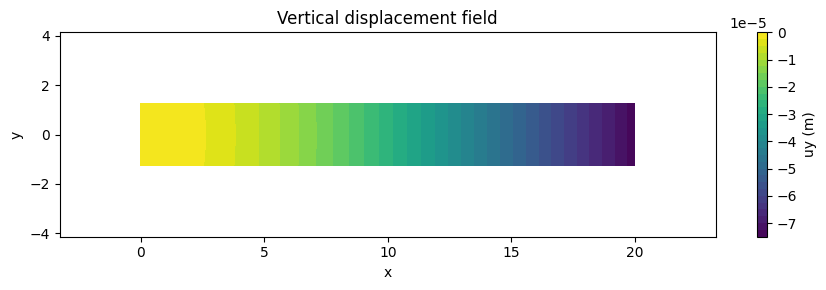

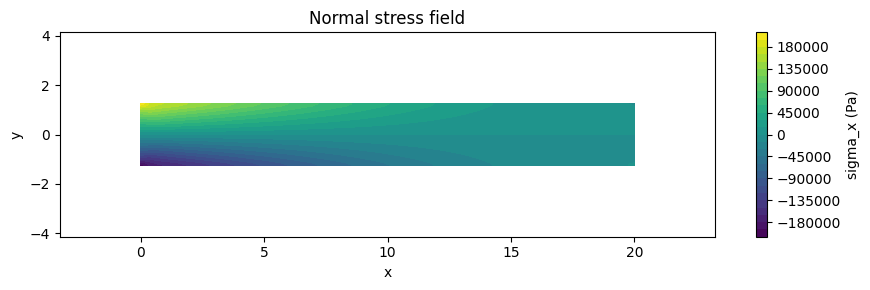

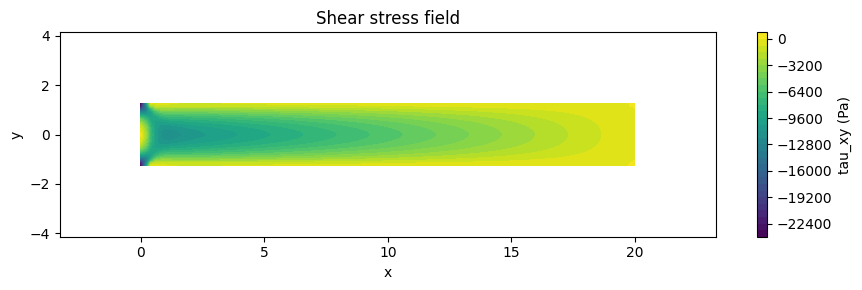

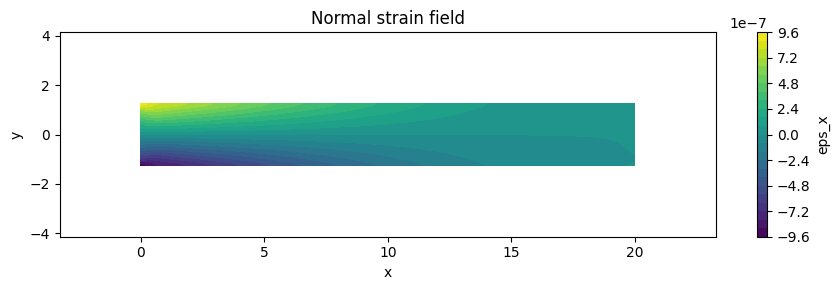

In [55]:
def quad_to_tri(elements):
    tris = []
    for n1, n2, n3, n4 in elements:
        tris.append([n1, n2, n3])
        tris.append([n1, n3, n4])
    return np.array(tris)


def nodal_average(nodes, elements, elem_df, column):
    val = np.zeros(len(nodes))
    count = np.zeros(len(nodes))

    for _, row in elem_df.iterrows():
        e = int(row["element"])
        for n in elements[e]:
            val[n] += row[column]
            count[n] += 1

    count[count == 0] = 1
    return val / count


def plot_nodal_field(result, values, title, label):
    nodes = result["nodes"]
    elements = result["elements"]
    tris = quad_to_tri(elements)

    plt.figure(figsize=(9, 3))
    cf = plt.tricontourf(nodes[:, 0], nodes[:, 1], tris, values, levels=30)
    plt.colorbar(cf, label=label)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()


nodes = static_result["nodes"]
U = static_result["U"]
elem_df = static_result["elem_df"]

ux = U[0::2]
uy = U[1::2]
sigma_x = nodal_average(nodes, static_result["elements"], elem_df, "sigma_x")
tau_xy = nodal_average(nodes, static_result["elements"], elem_df, "tau_xy")
sigma_y = nodal_average(nodes, static_result["elements"], elem_df, "sigma_y")
eps_x = nodal_average(nodes, static_result["elements"], elem_df, "eps_x")
eps_y = nodal_average(nodes, static_result["elements"], elem_df, "eps_y")
gamma_xy = nodal_average(nodes, static_result["elements"], elem_df, "gamma_xy")



plot_nodal_field(static_result, uy, "Vertical displacement field", "uy (m)")
plot_nodal_field(static_result, sigma_x, "Normal stress field", "sigma_x (Pa)")
plot_nodal_field(static_result, tau_xy, "Shear stress field", "tau_xy (Pa)")
plot_nodal_field(static_result, eps_x, "Normal strain field", "eps_x")

## Mesh convergence for \(L/H=50\)

In [56]:
def convergence_static_AR50(H, E, nu, rho, thickness, ty, ny_values):
    rows = []
    L50 = 50.0 * H

    for ny_i in ny_values:
        nx_i = int(round(50.0 * ny_i))
        A_i = np.array([L50 / 2.0, -H / 2.0])

        res = run_static_case(
            L=L50,
            H=H,
            nx=nx_i,
            ny=ny_i,
            E=E,
            nu=nu,
            rho=rho,
            thickness=thickness,
            ty=ty,
            point_A=A_i
        )

        rows.append({
            "ny": ny_i,
            "nx": nx_i,
            "elements": nx_i * ny_i,
            "nodes": len(res["nodes"]),
            "A_x": res["point_A_coord"][0],
            "A_y": res["point_A_coord"][1],
            "uy_A_m": res["point_A_uy"],
            "abs_uy_A_m": abs(res["point_A_uy"]),
            "strain_energy_J": res["strain_energy"]
        })

        print(f"nx={nx_i}, ny={ny_i}")

    df = pd.DataFrame(rows)
    df["change_uy_percent"] = df["abs_uy_A_m"].pct_change().abs() * 100.0
    df["change_energy_percent"] = df["strain_energy_J"].pct_change().abs() * 100.0
    return df



ny_values = []
for i in range(2, 21):
    ny_values.append(i)

conv_df = convergence_static_AR50(H, E, nu, rho, thickness, ty, ny_values)


nx=100, ny=2
nx=150, ny=3
nx=200, ny=4
nx=250, ny=5
nx=300, ny=6
nx=350, ny=7
nx=400, ny=8
nx=450, ny=9
nx=500, ny=10
nx=550, ny=11
nx=600, ny=12
nx=650, ny=13
nx=700, ny=14
nx=750, ny=15
nx=800, ny=16
nx=850, ny=17
nx=900, ny=18
nx=950, ny=19
nx=1000, ny=20


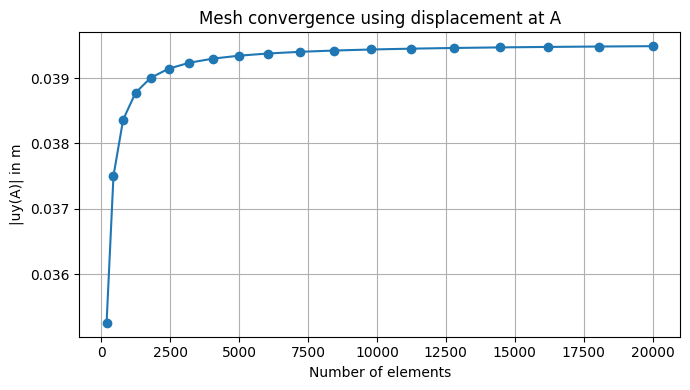

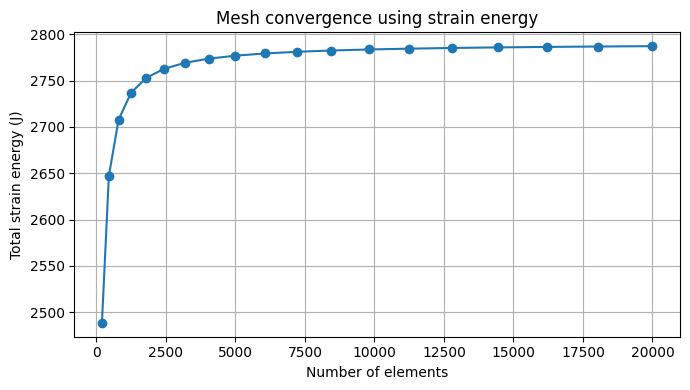

In [57]:
plt.figure(figsize=(7, 4))
plt.plot(conv_df["elements"], conv_df["abs_uy_A_m"], marker="o")
plt.xlabel("Number of elements")
plt.ylabel("|uy(A)| in m")
plt.title("Mesh convergence using displacement at A")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(conv_df["elements"], conv_df["strain_energy_J"], marker="o")
plt.xlabel("Number of elements")
plt.ylabel("Total strain energy (J)")
plt.title("Mesh convergence using strain energy")
plt.grid(True)
plt.tight_layout()
plt.show()

## Validation for \(L/H=50\)

In [58]:
best_ny = int(conv_df.iloc[-1]["ny"])
best_nx = int(conv_df.iloc[-1]["nx"])

L50 = 50.0 * H
A50 = np.array([L50 / 2.0, -H / 2.0])

best_static = run_static_case(
    L=L50,
    H=H,
    nx=best_nx,
    ny=best_ny,
    E=E,
    nu=nu,
    rho=rho,
    thickness=thickness,
    ty=ty,
    point_A=A50
)

ana50 = beam_theory_values(L50, H, thickness, E, nu, ty, x=L50/2.0)

validation_df = pd.DataFrame([
    {
        "method": "FEM",
        "uy_A_m": best_static["point_A_uy"],
        "strain_energy_J": best_static["strain_energy"]
    },
    {
        "method": "Euler-Bernoulli",
        "uy_A_m": ana50["EB_deflection_at_x"],
        "strain_energy_J": ana50["EB_strain_energy"]
    },
    {
        "method": "Timoshenko",
        "uy_A_m": ana50["Timoshenko_deflection_at_x"],
        "strain_energy_J": ana50["Timoshenko_strain_energy"]
    }
])

validation_df["error_vs_Timoshenko_uy_percent"] = (
    abs(validation_df["uy_A_m"] - ana50["Timoshenko_deflection_at_x"])
    / abs(ana50["Timoshenko_deflection_at_x"]) * 100.0
)

validation_df["error_vs_Timoshenko_energy_percent"] = (
    abs(validation_df["strain_energy_J"] - ana50["Timoshenko_strain_energy"])
    / abs(ana50["Timoshenko_strain_energy"]) * 100.0
)



## Aspect-ratio study

In [59]:
aspect_ratios = [2, 3, 5, 8, 10, 15, 20, 25, 30, 40, 50]

rows = []
ny_aspect = best_ny

for AR in aspect_ratios:
    L_i = AR * H
    nx_i = max(2, int(round(AR * ny_aspect)))
    A_i = np.array([L_i / 2.0, -H / 2.0])

    res = run_static_case(
        L=L_i,
        H=H,
        nx=nx_i,
        ny=ny_aspect,
        E=E,
        nu=nu,
        rho=rho,
        thickness=thickness,
        ty=ty,
        point_A=A_i
    )

    ana = beam_theory_values(L_i, H, thickness, E, nu, ty, x=L_i/2.0)

    rows.append({
        "L/H": AR,
        "L_m": L_i,
        "nx": nx_i,
        "ny": ny_aspect,
        "elements": nx_i * ny_aspect,
        "FEM_uy_A_m": res["point_A_uy"],
        "EB_uy_A_m": ana["EB_deflection_at_x"],
        "Timoshenko_uy_A_m": ana["Timoshenko_deflection_at_x"],
        "FEM_energy_J": res["strain_energy"],
        "EB_energy_J": ana["EB_strain_energy"],
        "Timoshenko_energy_J": ana["Timoshenko_strain_energy"]
    })

    print(f"Aspect ratio = {AR}")

aspect_df = pd.DataFrame(rows)

aspect_df["error_vs_EB_percent"] = (
    abs(aspect_df["FEM_uy_A_m"] - aspect_df["EB_uy_A_m"])
    / abs(aspect_df["EB_uy_A_m"]) * 100.0
)

aspect_df["error_vs_Timoshenko_percent"] = (
    abs(aspect_df["FEM_uy_A_m"] - aspect_df["Timoshenko_uy_A_m"])
    / abs(aspect_df["Timoshenko_uy_A_m"]) * 100.0
)



Aspect ratio = 2
Aspect ratio = 3
Aspect ratio = 5
Aspect ratio = 8
Aspect ratio = 10
Aspect ratio = 15
Aspect ratio = 20
Aspect ratio = 25
Aspect ratio = 30
Aspect ratio = 40
Aspect ratio = 50


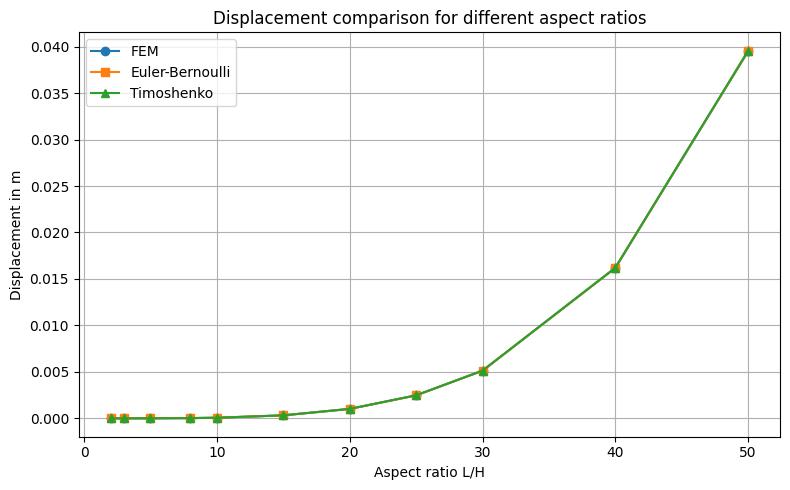

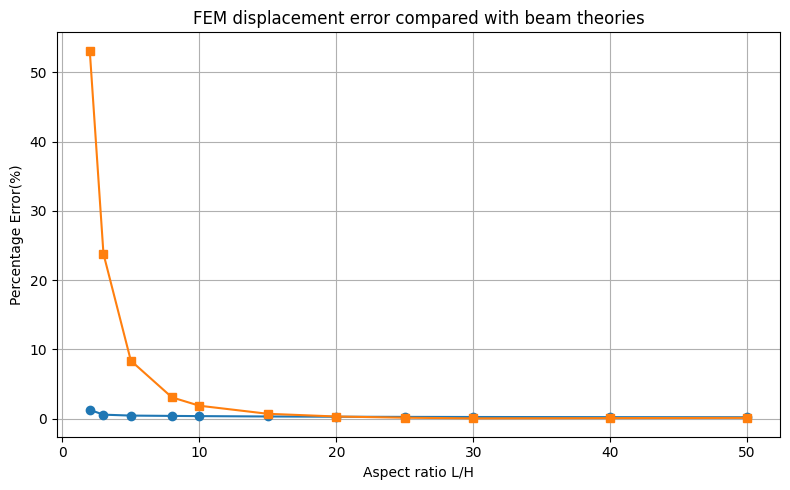

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(aspect_df["L/H"], abs(aspect_df["FEM_uy_A_m"]), marker="o", label="FEM")
plt.plot(aspect_df["L/H"], abs(aspect_df["EB_uy_A_m"]), marker="s", label="Euler-Bernoulli")
plt.plot(aspect_df["L/H"], abs(aspect_df["Timoshenko_uy_A_m"]), marker="^", label="Timoshenko")
plt.xlabel("Aspect ratio L/H")
plt.ylabel("Displacement in m")
plt.title("Displacement comparison for different aspect ratios")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(aspect_df["L/H"], aspect_df["error_vs_Timoshenko_percent"], marker="o", label="Error vs Timoshenko")
plt.plot(aspect_df["L/H"], aspect_df["error_vs_EB_percent"], marker="s", label="Error vs Euler-Bernoulli")
plt.xlabel("Aspect ratio L/H")
plt.ylabel("Percentage Error(%)")
plt.title("FEM displacement error compared with beam theories")
plt.grid(True)
plt.tight_layout()
plt.show()

## Shear stress through the thickness at \(x=L/10\), \(L/H=50\)

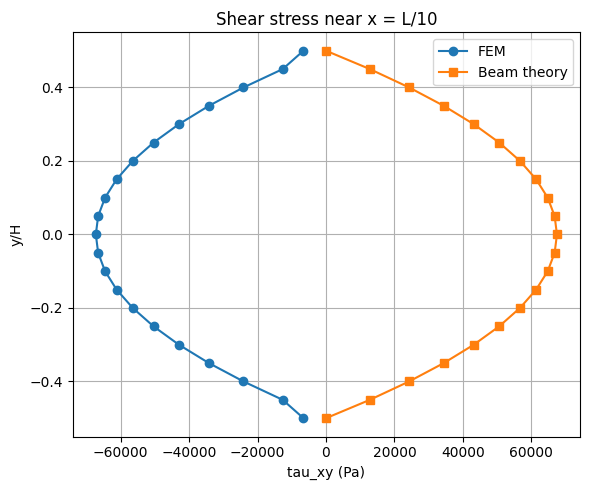

In [61]:
def shear_stress_at_section(result, ty, thickness, x_fraction=0.1):
    nodes = result["nodes"]
    elements = result["elements"]
    elem_df = result["elem_df"]
    L = result["L"]
    H = result["H"]

    tau_nodes = nodal_average(nodes, elements, elem_df, "tau_xy")

    x_target = x_fraction * L
    x_values = np.unique(np.round(nodes[:, 0], 12))
    x_used = x_values[np.argmin(abs(x_values - x_target))]

    ids = np.where(np.isclose(nodes[:, 0], x_used))[0]
    ids = ids[np.argsort(nodes[ids, 1])]

    y = nodes[ids, 1]
    tau_fem = tau_nodes[ids]

    A = thickness * H
    V = ty * (L - x_used)
    tau_beam = (3.0 * V / (2.0 * A)) * (1.0 - 4.0 * y**2 / H**2)

    df = pd.DataFrame({
        "x_used_m": x_used,
        "y_m": y,
        "y_by_H": y / H,
        "tau_xy_FEM_Pa": tau_fem,
        "tau_xy_beam_Pa": tau_beam
    })

    plt.figure(figsize=(6, 5))
    plt.plot(tau_fem, y / H, marker="o", label="FEM")
    plt.plot(tau_beam, y / H, marker="s", label="Beam theory")
    plt.xlabel("tau_xy (Pa)")
    plt.ylabel("y/H")
    plt.title(f"Shear stress near x = L/10")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df


shear_df = shear_stress_at_section(best_static, ty, thickness, x_fraction=0.1)


## Modal analysis

In [62]:
def solve_modal_case(L, H, nx, ny, E, nu, rho, thickness, n_modes=5):
    nodes, elements = make_mesh(L, H, nx, ny)
    K, M = assemble(nodes, elements, E, nu, rho, thickness)

    fixed = fixed_left_dofs(nodes)
    all_dofs = np.arange(K.shape[0])
    free = np.setdiff1d(all_dofs, fixed)

    Kff = K[free, :][:, free]
    Mff = M[free, :][:, free]

    vals, vecs_free = eigsh(Kff, k=n_modes, M=Mff, sigma=0.0, which="LM")

    order = np.argsort(vals)
    vals = vals[order]
    vecs_free = vecs_free[:, order]

    omega = np.sqrt(np.abs(vals))
    freq = omega / (2.0 * np.pi)

    modes = []
    for i in range(n_modes):
        u = np.zeros(K.shape[0])
        u[free] = vecs_free[:, i]

        m = np.max(np.abs(u))
        if m > 0:
            u = u / m

        modes.append(u)

    return {
        "L": L,
        "H": H,
        "nx": nx,
        "ny": ny,
        "nodes": nodes,
        "elements": elements,
        "K": K,
        "M": M,
        "freq_hz": freq,
        "omega_rad_s": omega,
        "modes": modes
    }


def plot_mode_shape(modal_result, mode_number, scale=0.15):
    nodes = modal_result["nodes"]
    elements = modal_result["elements"]
    mode = modal_result["modes"][mode_number - 1]

    ux = mode[0::2]
    uy = mode[1::2]

    L = modal_result["L"]
    x_def = nodes[:, 0] + scale * L * ux
    y_def = nodes[:, 1] + scale * L * uy

    tris = quad_to_tri(elements)

    plt.figure(figsize=(9, 3))
    cf = plt.tricontourf(x_def, y_def, tris, uy, levels=30)
    plt.colorbar(cf, label="normalized uy")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Mode {mode_number}: f = {modal_result['freq_hz'][mode_number-1]:.4f} Hz")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

In [63]:

L_modal = 50.0 * H
ny_modal = best_ny
nx_modal = int(round(50.0 * ny_modal))

modal_result = solve_modal_case(
    L=L_modal,
    H=H,
    nx=nx_modal,
    ny=ny_modal,
    E=E,
    nu=nu,
    rho=rho,
    thickness=thickness,
    n_modes=5
)

freq_df = pd.DataFrame({
    "mode": np.arange(1, 6),
    "omega_rad_per_s": modal_result["omega_rad_s"],
    "frequency_Hz": modal_result["freq_hz"]
})

freq_df

,mode,omega_rad_per_s,frequency_Hz
0,1,0.840394,0.133753
1,2,5.256885,0.836659
2,3,14.675767,2.335721
3,4,28.635382,4.557463
4,5,47.076552,7.492466


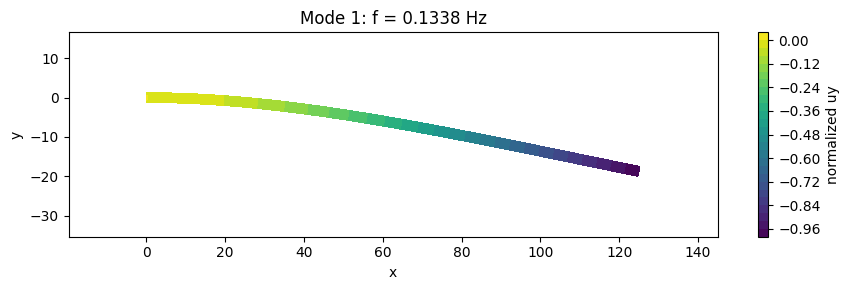

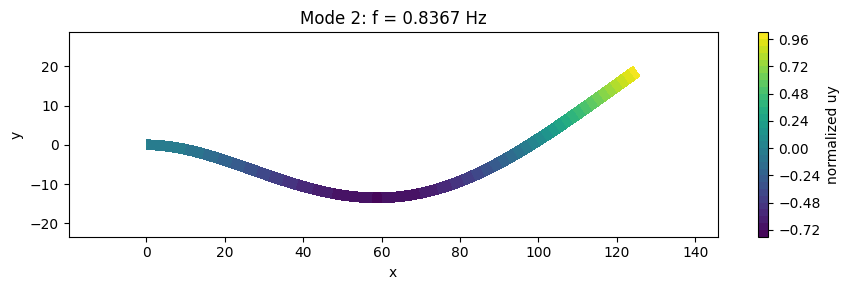

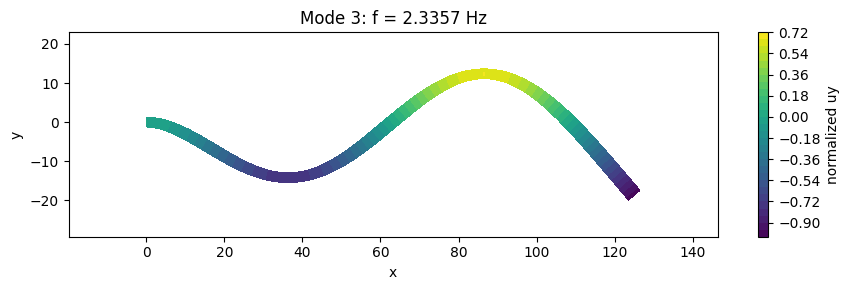

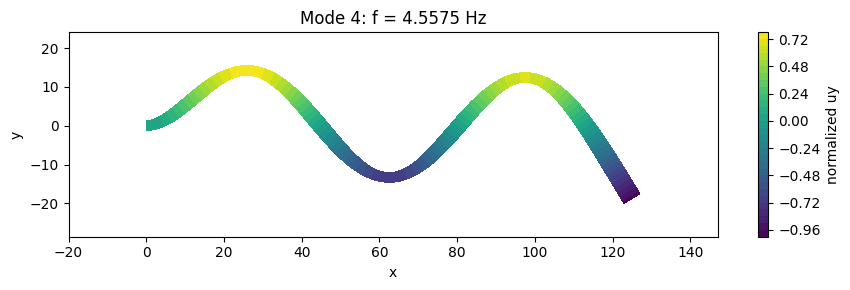

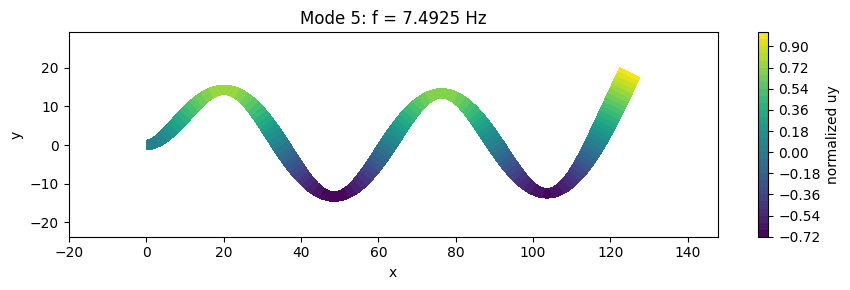

In [64]:
for mode_no in range(1, 6):
    plot_mode_shape(modal_result, mode_no, scale=0.15)

## Mesh convergence for the 5th natural frequency

In [65]:
def modal_convergence_5th_frequency(H, E, nu, rho, thickness, ny_values):
    rows = []
    L50 = 50.0 * H

    for ny_i in ny_values:
        nx_i = int(round(50.0 * ny_i))

        res = solve_modal_case(
            L=L50,
            H=H,
            nx=nx_i,
            ny=ny_i,
            E=E,
            nu=nu,
            rho=rho,
            thickness=thickness,
            n_modes=5
        )

        rows.append({
            "ny": ny_i,
            "nx": nx_i,
            "elements": nx_i * ny_i,
            "f5_Hz": res["freq_hz"][4]
        })

        print(f"nx={nx_i}, ny={ny_i}, f5={res['freq_hz'][4]:.4f} Hz")

    df = pd.DataFrame(rows)
    df["change_f5_percent"] = df["f5_Hz"].pct_change().abs() * 100.0
    return df


# Use fewer points for modal convergence because eigenvalue problems are heavier.
modal_ny_values = []
for i in range(2, 21):
    modal_ny_values.append(i)
modal_conv_df = modal_convergence_5th_frequency(H, E, nu, rho, thickness, modal_ny_values)


nx=100, ny=2, f5=7.9506 Hz
nx=150, ny=3, f5=7.6979 Hz
nx=200, ny=4, f5=7.6069 Hz
nx=250, ny=5, f5=7.5644 Hz
nx=300, ny=6, f5=7.5411 Hz
nx=350, ny=7, f5=7.5270 Hz
nx=400, ny=8, f5=7.5178 Hz
nx=450, ny=9, f5=7.5115 Hz
nx=500, ny=10, f5=7.5070 Hz
nx=550, ny=11, f5=7.5036 Hz
nx=600, ny=12, f5=7.5011 Hz
nx=650, ny=13, f5=7.4991 Hz
nx=700, ny=14, f5=7.4975 Hz
nx=750, ny=15, f5=7.4963 Hz
nx=800, ny=16, f5=7.4952 Hz
nx=850, ny=17, f5=7.4943 Hz
nx=900, ny=18, f5=7.4936 Hz
nx=950, ny=19, f5=7.4930 Hz
nx=1000, ny=20, f5=7.4925 Hz


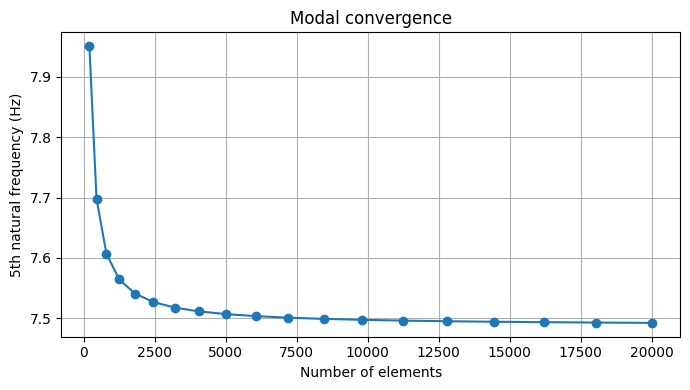

In [66]:
plt.figure(figsize=(7, 4))
plt.plot(modal_conv_df["elements"], modal_conv_df["f5_Hz"], marker="o")
plt.xlabel("Number of elements")
plt.ylabel("5th natural frequency (Hz)")
plt.title("Modal convergence")
plt.grid(True)
plt.tight_layout()
plt.show()